# CPWC Linear Array (Verasonics L7)

Coherent Plane Wave Compound imaging with a 128-element linear array.
15 plane waves are compounded to form a high-quality image of point scatterers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

## Download and read dataset

In [2]:
DATA_URL = "https://www.ustb.no/datasets/"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
filename = "L7_CPWC_193328.uff"
filepath = os.path.join(DATA_PATH, filename)

if not os.path.exists(filepath):
    os.makedirs(DATA_PATH, exist_ok=True)
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(DATA_URL + filename, filepath)

from pyuff_ustb.objects.uff import Uff
channel_data = Uff(filepath).read("channel_data")

print(f"Channel data: {channel_data.N_samples} samples, "
      f"{channel_data.N_channels} channels, "
      f"{channel_data.N_waves} waves, "
      f"{channel_data.N_frames} frames")

Channel data: 1920 samples, 128 channels, 15 waves, 3 frames


## Define linear scan

In [3]:
from pyuff_ustb.objects import LinearScan

probe_x = channel_data.probe.x
scan = LinearScan()
scan.__dict__["x_axis"] = np.linspace(float(probe_x.min()), float(probe_x.max()), 256)
scan.__dict__["z_axis"] = np.linspace(0, 50e-3, 256)

print(f"Scan: {len(scan.x_axis)} × {len(scan.z_axis)} = {scan.x.size} pixels")

Scan: 256 × 256 = 65536 pixels


## Beamform with DAS

In [4]:
from ustb.midprocess import DAS
from ustb.enums import Dimension, Window

mid = DAS()
mid.channel_data = channel_data
mid.scan = scan
mid.dimension = Dimension.both
mid.transmit_apodization.window = Window.none
mid.transmit_apodization.f_number = np.array([1.7, 1.7])
mid.receive_apodization.window = Window.none
mid.receive_apodization.f_number = np.array([1.7, 1.7])

b_data = mid.go()

/home/ubuntu/.local/lib/python3.12/site-packages/pyuff_ustb/objects/point.py:60: RuntimeWarning: invalid value encountered in multiply
  return self.distance * np.sin(self.elevation)
/home/ubuntu/.local/lib/python3.12/site-packages/pyuff_ustb/objects/point.py:56: RuntimeWarning: invalid value encountered in multiply
  return self.distance * np.sin(self.azimuth) * np.cos(self.elevation)


USTB Python beamformer...

Completed in 8.41 seconds.


## Display B-mode image

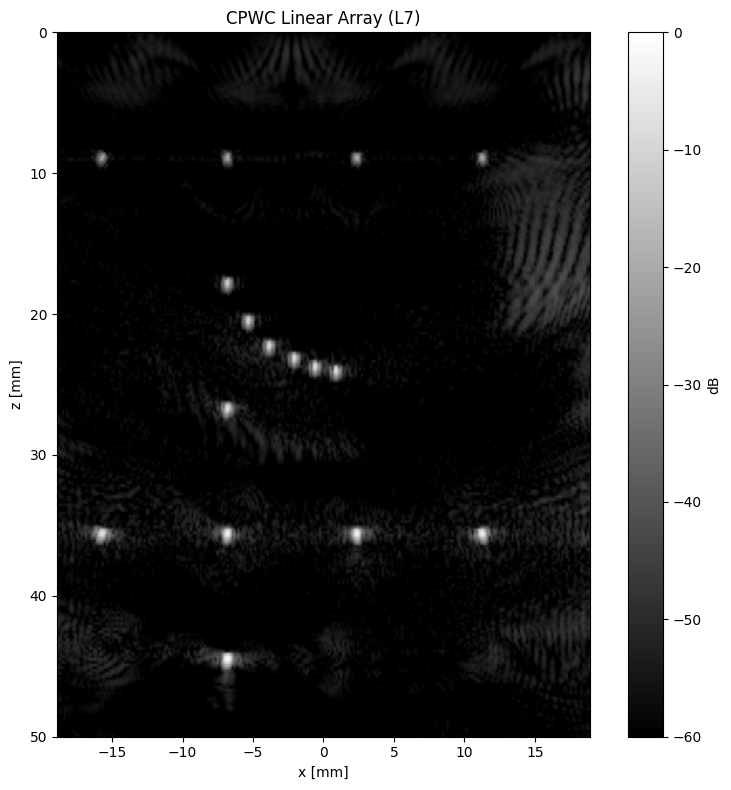

In [5]:
fig, ax = b_data.plot(title="CPWC Linear Array (L7)", dynamic_range=60)
plt.show()